# 🔋 Simulasi Extended Kalman Filter (EKF) Berbasis Model Baterai CSV

**Tujuan:** Mengimplementasikan algoritma *Extended Kalman Filter* (EKF) untuk estimasi State of Charge (SOC) baterai LiFePO4. Model matematika (OCV dan ECM 1RC) diimpor dari hasil ekstraksi yang disimpan dalam format `Model_Baterai_EKF.csv`. Simulasi ini memvalidasi algoritma pada dua jenis pengujian: Profil Beban Statis (Charge-Rest) dan Profil Beban Dinamis (Urban Load).

**Tuning Matriks EKF (Sesuai Bab 3):**
Berdasarkan hasil *Grid Search*, konfigurasi optimal matriks *Process Noise* ($Q$) dan *Measurement Noise* ($R$) yang menyesuaikan dengan resolusi instrumen ZKETECH EBC-A40L adalah:
$$Q_{\text{final}} = \begin{bmatrix} 10^{-5} & 0 \\ 0 & 10^{-4} \end{bmatrix}, \quad R_{\text{final}} = 10^{-4}\ \text{V}^2$$

**Dataset:**
1. `Model_Baterai_EKF.csv` (Berisi Kapasitas, Tabel OCV, dan Parameter R0, R1, C1).
2. `charge-rest 60m.csv` (Data simulasi beban statis / charging).
3. `Dynamic Profiling (Urban Load).csv` (Data simulasi beban dinamis).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
from scipy.interpolate import interp1d

# Konfigurasi Tampilan Plot
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 12

---
## 1️⃣ IMPORT MODEL PARAMETER (DARI CUSTOM CSV)
Membaca file `Model_Baterai_EKF.csv` yang memiliki struktur multi-tabel. Data dipecah menjadi tiga bagian utama:
* **Battery Parameters:** Kapasitas nominal baterai dalam Coulomb ($Q_c$).
* **OCV Lookup Table:** Kurva relasi tegangan relaksasi terhadap SOC.
* **ECM Parameters:** Karakteristik dinamika sirkuit $R_0, R_1, C_1$.
Semua tabel diinterpolasi menjadi fungsi Python berkesinambungan.

In [2]:
# =========================================================
# MEMUAT FILE MODEL BATERAI (MULTI-SECTION CSV)
# =========================================================
print("⏳ Memuat model dari Model_Baterai_EKF.csv...")

try:
    with open('Model_Baterai_EKF.csv', 'r') as f:
        text = f.read()

    # 1. Ekstraksi Battery Parameters
    param_str = text.split('=== BATTERY PARAMETERS ===')[1].split('=== OCV LOOKUP TABLE ===')[0].strip()
    df_params = pd.read_csv(io.StringIO(param_str))
    Q_Ah = float(df_params[df_params['Parameter'] == 'Q_Ah_Nominal']['Value'].values[0])
    Q_Coulomb = float(df_params[df_params['Parameter'] == 'Q_As']['Value'].values[0])
    print(f"✅ Kapasitas: {Q_Ah:.2f} Ah ({Q_Coulomb:.2f} Coulomb)")

    # 2. Ekstraksi OCV Lookup Table
    ocv_str = text.split('=== OCV LOOKUP TABLE ===')[1].split('=== ECM PARAMETERS (1-RC Thevenin) ===')[0].strip()
    df_ocv = pd.read_csv(io.StringIO(ocv_str))
    f_OCV_LUT = interp1d(
        df_ocv['SOC'], df_ocv['OCV_V'], 
        kind='linear', bounds_error=False, 
        fill_value=(df_ocv['OCV_V'].iloc[0], df_ocv['OCV_V'].iloc[-1])
    )

    # 3. Ekstraksi ECM Parameters
    ecm_str = text.split('=== ECM PARAMETERS (1-RC Thevenin) ===')[1].strip()
    df_ecm = pd.read_csv(io.StringIO(ecm_str))

    # Bersihkan df_ecm: konversi SOC_percent ke numeric dan drop baris non-numeric
    df_ecm['SOC_percent'] = pd.to_numeric(df_ecm['SOC_percent'], errors='coerce')
    df_ecm = df_ecm.dropna()

    soc_ecm_scale = df_ecm['SOC_percent'] 
    if soc_ecm_scale.max() > 2.0:
        soc_ecm_scale = soc_ecm_scale / 100.0

    f_R0 = interp1d(soc_ecm_scale, df_ecm['R0_ohm'], fill_value='extrapolate')
    f_R1 = interp1d(soc_ecm_scale, df_ecm['R1_ohm'], fill_value='extrapolate')
    f_C1 = interp1d(soc_ecm_scale, df_ecm['C1_farad'], fill_value='extrapolate')

    print("✅ Fungsi Interpolasi OCV dan ECM (R0, R1, C1) berhasil dibuat!")
except Exception as e:
    print(f"❌ Gagal memuat model: {e}")

⏳ Memuat model dari Model_Baterai_EKF.csv...
✅ Kapasitas: 20.80 Ah (74874.80 Coulomb)
✅ Fungsi Interpolasi OCV dan ECM (R0, R1, C1) berhasil dibuat!


---
## 2️⃣ ALGORITMA EXTENDED KALMAN FILTER (EKF)

Model State-Space diskrit dieksekusi menggunakan algoritma Extended Kalman Filter (EKF). 
Class EKF dibungkus agar dapat dipanggil berkali-kali untuk dataset yang berbeda (Statis & Dinamis).

In [3]:
# =========================================================
# KELAS EXTENDED KALMAN FILTER (EKF) - TUNED PARAMETERS
# =========================================================
class EKF_BMS:
    def __init__(self, Q_Coulomb, f_ocv, f_r0, f_r1, f_c1):
        self.Q_c = Q_Coulomb  
        self.x = np.array([[1.0], [0.0]]) # State awal: [SOC, Vc1]
        self.P = np.array([[1e-2, 0], [0, 1e-2]])
        
        # Matrix Noise Hasil Grid Search
        self.Q_noise = np.array([[1e-5, 0], 
                                 [0, 1e-4]]) 
        self.R_noise = np.array([[1e-4]]) 
        
        # Fungsi Interpolasi
        self.f_ocv = f_ocv
        self.f_r0 = f_r0
        self.f_r1 = f_r1
        self.f_c1 = f_c1
        self.I2 = np.eye(2) 
        
    def get_dOCV_dSOC(self, soc_val):
        """ Turunan Numerik Central Difference (Jacobian H) """
        delta = 0.001
        s_high = min(soc_val + delta, 1.0)
        s_low = max(soc_val - delta, 0.0)
        derivative = (float(self.f_ocv(s_high)) - float(self.f_ocv(s_low))) / (s_high - s_low)
        return max(float(derivative), 1e-6)

    def step(self, I_meas, V_meas, dt):
        soc_prev = np.clip(float(self.x[0, 0]), 0.0, 1.0)
        vc1_prev = float(self.x[1, 0])
        
        # Ambil Parameter ECM sesuai SOC saat ini
        R0 = max(float(self.f_r0(soc_prev)), 1e-4)
        R1 = max(float(self.f_r1(soc_prev)), 1e-4)
        C1 = max(float(self.f_c1(soc_prev)), 1.0)
        tau = max(R1 * C1, 1e-6)
        
        # --- TAHAP 1: PREDIKSI (A PRIORI) ---
        # Arus (I) bernilai Positif saat Discharge, Negatif saat Charge
        soc_pred = soc_prev - (I_meas * dt / self.Q_c)
        soc_pred = np.clip(soc_pred, 0.0, 1.0)
        
        alpha = np.exp(-dt / tau) if dt > 0 else 1.0
        vc1_pred = (alpha * vc1_prev) + (R1 * (1.0 - alpha) * I_meas)
        
        self.x = np.array([[soc_pred], [vc1_pred]])
        A = np.array([[1.0, 0.0], [0.0, alpha]])
        self.P = A @ self.P @ A.T + self.Q_noise
        
        # --- TAHAP 2: UPDATE (A POSTERIORI) ---
        OCV_pred = float(self.f_ocv(soc_pred))
        dOCV_dSOC = self.get_dOCV_dSOC(soc_pred)
        
        V_pred = OCV_pred - vc1_pred - (I_meas * R0)
        H = np.array([[dOCV_dSOC, -1.0]])
        
        S = H @ self.P @ H.T + self.R_noise
        K = self.P @ H.T @ np.linalg.inv(S)
        
        error = V_meas - V_pred
        
        self.x = self.x + (K * error)
        self.x[0, 0] = np.clip(self.x[0, 0], 0.0, 1.0)
        
        # Update Kovariansi P (Joseph Form)
        I_KH = self.I2 - K @ H
        self.P = I_KH @ self.P @ I_KH.T + K @ self.R_noise @ K.T
        
        return float(self.x[0, 0]), V_pred

---
## 3️⃣ FUNGSI BANTU (HELPER) UNTUK DATA & SIMULASI
Membuat fungsi universal untuk memuat data *logger* ZKETECH dan menjalankan iterasi simulasi EKF agar kode lebih ringkas saat memanggil file yang berbeda.

In [4]:
# =========================================================
# HELPER FUNCTIONS & INVERSE OCV
# =========================================================
# Buat fungsi Inverse OCV untuk mencari SOC awal dari Tegangan awal secara presisi
f_SOC_from_OCV = interp1d(
    df_ocv['OCV_V'], df_ocv['SOC'], 
    kind='linear', bounds_error=False, 
    fill_value=(df_ocv['SOC'].iloc[0], df_ocv['SOC'].iloc[-1])
)

def load_zke_data(filepath):
    """Membaca file CSV ZKETECH, mengabaikan header, dan menghitung dt"""
    skip_rows = 0
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if "Time(S)" in line:
                skip_rows = i
                break
    df = pd.read_csv(filepath, skiprows=skip_rows)
    df.columns = [col.strip() for col in df.columns]
    
    # Kalkulasi Delta Time (dt)
    df['dt'] = df['Time(S)'].diff().fillna(0)
    return df

def run_simulation(df_input, initial_soc):
    """Menjalankan EKF dan Coulomb Counting pada dataset"""
    ekf = EKF_BMS(Q_Coulomb, f_OCV_LUT, f_R0, f_R1, f_C1)
    ekf.x[0, 0] = initial_soc # Set initial state sama persis untuk EKF
    
    soc_history = []
    v_pred_history = []
    
    for i in range(len(df_input)):
        i_actual = df_input['Cur(A)'].iloc[i]
        
        # Deteksi otomatis apakah ini proses Charge atau Discharge
        # Jika rata-rata tegangan naik dan arus positif -> Ini proses Charging (arus harus negatif untuk EKF)
        if df_input['Vol(V)'].iloc[-1] > df_input['Vol(V)'].iloc[0] and i_actual > 0:
            i_actual = -i_actual 
            
        soc_est, v_pred = ekf.step(i_actual, df_input['Vol(V)'].iloc[i], df_input['dt'].iloc[i])
        soc_history.append(soc_est)
        v_pred_history.append(v_pred)
    
    # Coulomb Counting Baseline (Mulai dari titik yang sama dengan EKF)
    i_cc = df_input['Cur(A)']
    if df_input['Vol(V)'].iloc[-1] > df_input['Vol(V)'].iloc[0] and i_cc.mean() > 0:
         i_cc = -i_cc
            
    coulomb_discharged = (i_cc * df_input['dt']).cumsum()
    soc_cc = initial_soc - (coulomb_discharged / Q_Coulomb)
    
    return soc_history, v_pred_history, soc_cc

---
## 4️⃣ VALIDASI PROFIL BEBAN STATIS (CHARGE-REST)
Percobaan ini menggunakan file `charge-rest 60m.csv`. Tujuannya untuk mengamati respon EKF terhadap arus konstan dan kemampuan relaksasi (Rest) menggunakan komponen $R_1$ dan $C_1$. Titik start (Initial SOC) dikalkulasi presisi menggunakan *Inverse OCV Lookup*.

⏳ Menjalankan Simulasi Profil Statis (Charge-Rest)...
Berdasarkan V_awal (2.487V), SOC awal diset ke: 0.00%


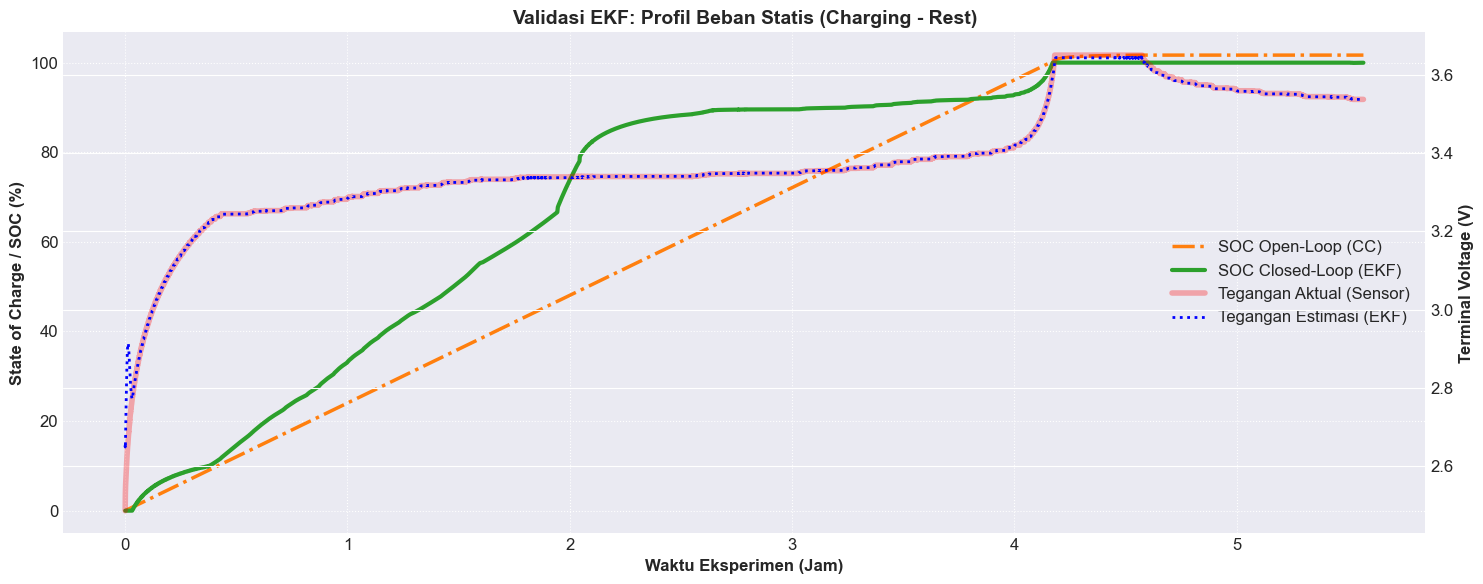

📊 KOMPARASI PERFORMA: PROFIL STATIS
RMSE Tegangan EKF : 13.25 mV
Deviasi SOC Akhir (EKF vs CC) : 1.70%


In [5]:
# =========================================================
# EKSEKUSI PROFIL STATIS (CHARGE-REST)
# =========================================================
print("⏳ Menjalankan Simulasi Profil Statis (Charge-Rest)...")
df_static = load_zke_data('charge-rest 60m.csv')

# Cari SOC awal secara presisi dari pembacaan tegangan pertama sensor
v_init_static = df_static['Vol(V)'].iloc[0]
soc_init_exact_static = float(f_SOC_from_OCV(v_init_static))
print(f"Berdasarkan V_awal ({v_init_static}V), SOC awal diset ke: {soc_init_exact_static*100:.2f}%")

soc_ekf_static, v_pred_static, soc_cc_static = run_simulation(df_static, initial_soc=soc_init_exact_static)

df_static['SOC_EKF'] = soc_ekf_static
df_static['V_Pred'] = v_pred_static
df_static['SOC_CC'] = soc_cc_static

# --- Visualisasi Statis (Twin Axes) ---
fig, ax1 = plt.subplots(figsize=(15, 6))
ax2 = ax1.twinx()
t_hrs_static = df_static['Time(S)'] / 3600.0

# Plot SOC (Kiri)
l1 = ax1.plot(t_hrs_static, df_static['SOC_CC'] * 100, label='SOC Open-Loop (CC)', color='tab:orange', linestyle='-.', linewidth=2.5)
l2 = ax1.plot(t_hrs_static, df_static['SOC_EKF'] * 100, label='SOC Closed-Loop (EKF)', color='tab:green', linewidth=3)
ax1.set_xlabel('Waktu Eksperimen (Jam)', fontweight='bold')
ax1.set_ylabel('State of Charge / SOC (%)', fontweight='bold')

# Plot Voltage (Kanan)
l3 = ax2.plot(t_hrs_static, df_static['Vol(V)'], label='Tegangan Aktual (Sensor)', color='red', alpha=0.3, linewidth=4)
l4 = ax2.plot(t_hrs_static, df_static['V_Pred'], label='Tegangan Estimasi (EKF)', color='blue', linestyle=':', linewidth=2)
ax2.set_ylabel('Terminal Voltage (V)', fontweight='bold')

# Legend Gabungan
lines = l1 + l2 + l3 + l4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', framealpha=0.9)

plt.title('Validasi EKF: Profil Beban Statis (Charging - Rest)', fontweight='bold', fontsize=14)
ax1.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

# Komparasi Performa Statis
rmse_v_static = np.sqrt(np.mean((df_static['Vol(V)'] - df_static['V_Pred'])**2))
print("="*50)
print(f"📊 KOMPARASI PERFORMA: PROFIL STATIS")
print("="*50)
print(f"RMSE Tegangan EKF : {rmse_v_static*1000:.2f} mV")
print(f"Deviasi SOC Akhir (EKF vs CC) : {abs((df_static['SOC_EKF'].iloc[-1] - df_static['SOC_CC'].iloc[-1]) * 100):.2f}%")
print("="*50)

---
## 5️⃣ VALIDASI PROFIL BEBAN DINAMIS (URBAN LOAD)
Iterasi algoritma dieksekusi menggunakan `Dynamic Profiling (Urban Load).csv`. Sama seperti sebelumnya, *Initial SOC* dibaca langsung dari sensor tegangan di detik ke-0 untuk mencegah lompatan *Kalman Gain* yang drastis di fase awal.

⏳ Menjalankan Simulasi Profil Dinamis (Urban Load)...
Berdasarkan V_awal (3.42V), SOC awal diset ke: 94.14%


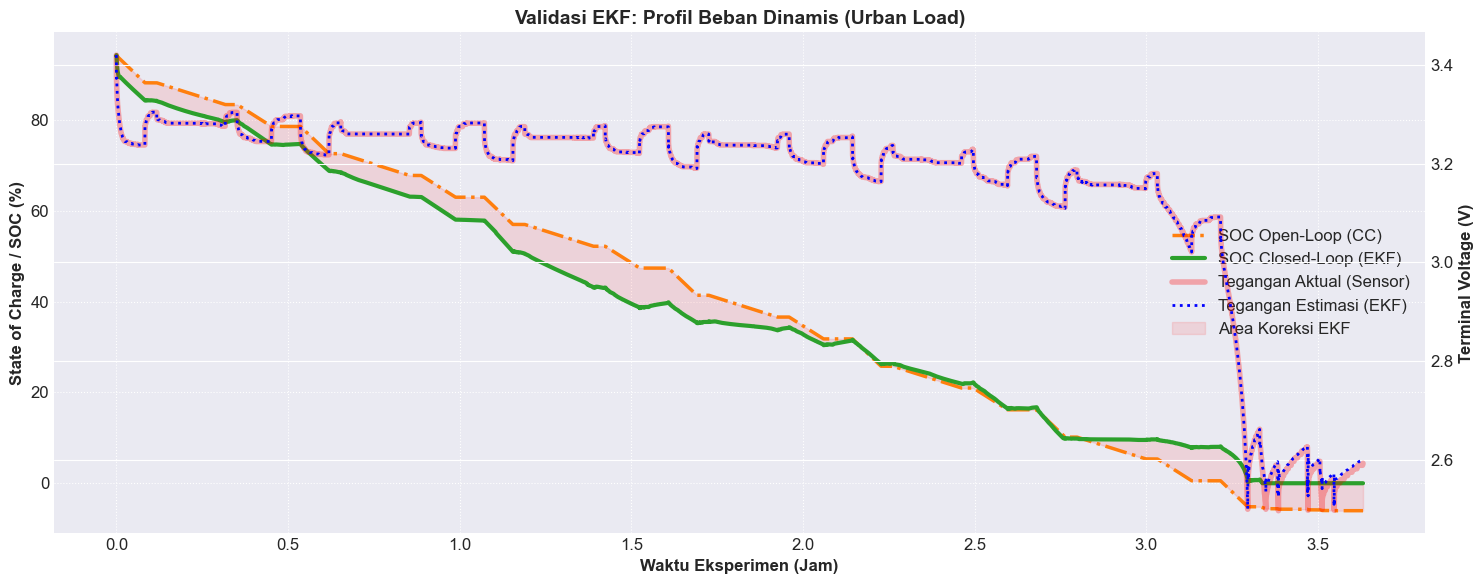

📊 KOMPARASI PERFORMA: PROFIL DINAMIS
RMSE Tegangan EKF : 4.15 mV
Deviasi SOC Akhir (EKF vs CC) : 6.04%


In [6]:
# =========================================================
# EKSEKUSI PROFIL DINAMIS (URBAN LOAD)
# =========================================================
print("⏳ Menjalankan Simulasi Profil Dinamis (Urban Load)...")
df_urban = load_zke_data("Dynamic Profiling (Urban Load).csv")

# Cari SOC awal secara presisi dari pembacaan tegangan pertama sensor
v_init_urban = df_urban['Vol(V)'].iloc[0]
soc_init_exact_urban = float(f_SOC_from_OCV(v_init_urban))
print(f"Berdasarkan V_awal ({v_init_urban}V), SOC awal diset ke: {soc_init_exact_urban*100:.2f}%")

soc_ekf_urban, v_pred_urban, soc_cc_urban = run_simulation(df_urban, initial_soc=soc_init_exact_urban)

df_urban['SOC_EKF'] = soc_ekf_urban
df_urban['SOC_CC'] = soc_cc_urban
df_urban['V_Pred'] = v_pred_urban

# --- Visualisasi Dinamis (Twin Axes) ---
fig, ax1 = plt.subplots(figsize=(15, 6))
ax2 = ax1.twinx()
t_hrs_urban = df_urban['Time(S)'] / 3600.0

# Plot SOC (Kiri)
l1 = ax1.plot(t_hrs_urban, df_urban['SOC_CC'] * 100, label='SOC Open-Loop (CC)', color='tab:orange', linestyle='-.', linewidth=2.5)
l2 = ax1.plot(t_hrs_urban, df_urban['SOC_EKF'] * 100, label='SOC Closed-Loop (EKF)', color='tab:green', linewidth=3)
ax1.fill_between(t_hrs_urban, df_urban['SOC_CC'] * 100, df_urban['SOC_EKF'] * 100, color='red', alpha=0.1, label='Koreksi EKF (Kalman Adjustment)')
ax1.set_xlabel('Waktu Eksperimen (Jam)', fontweight='bold')
ax1.set_ylabel('State of Charge / SOC (%)', fontweight='bold')

# Plot Voltage (Kanan)
l3 = ax2.plot(t_hrs_urban, df_urban['Vol(V)'], label='Tegangan Aktual (Sensor)', color='red', alpha=0.3, linewidth=4)
l4 = ax2.plot(t_hrs_urban, df_urban['V_Pred'], label='Tegangan Estimasi (EKF)', color='blue', linestyle=':', linewidth=2)
ax2.set_ylabel('Terminal Voltage (V)', fontweight='bold')

# Legend Gabungan (tambahkan fill_between ke legend secara manual)
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', alpha=0.1, label='Area Koreksi EKF')
lines = l1 + l2 + l3 + l4
labels = [l.get_label() for l in lines]
ax1.legend(lines + [red_patch], labels + ['Area Koreksi EKF'], loc='center right', framealpha=0.9)

plt.title('Validasi EKF: Profil Beban Dinamis (Urban Load)', fontweight='bold', fontsize=14)
ax1.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

# Komparasi Performa Dinamis
rmse_v_urban = np.sqrt(np.mean((df_urban['Vol(V)'] - df_urban['V_Pred'])**2))
print("="*50)
print(f"📊 KOMPARASI PERFORMA: PROFIL DINAMIS")
print("="*50)
print(f"RMSE Tegangan EKF : {rmse_v_urban*1000:.2f} mV")
print(f"Deviasi SOC Akhir (EKF vs CC) : {abs((df_urban['SOC_EKF'].iloc[-1] - df_urban['SOC_CC'].iloc[-1]) * 100):.2f}%")
print("="*50)